# 4D Coil Sketching: Local Test

## 1 - Module imports

In [1]:
%load_ext autoreload
%autoreload 2
import os
import sys
from pathlib import Path
for path in ['../src', '../sigpy_mod']:
    if path not in sys.path:
        sys.path.append(path)

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import sigpy as sp
import sigpy.mri as mr
import sigpy.plot as pl
import cupy as cp
from monitor_gpu import monitor_gpu_memory
from utils import coil_compression, create_montage, crop_2d, crop_center
import csm

/mnt/common/Precision/Biostats/asandhu/miniconda3/envs/coil-sketching-4d-bcchr/lib/python3.11/site-packages/sigpy/config.py:27: UserWarning: Importing cupy.cuda.cudnn failed. For more details, see the error stack below:
No module named 'cupyx.cudnn'
  warnings.warn(


## 2 - Configurations

In [2]:
class Config:
    # Hardware & Methods
    devnum = 0 # -1 for CPU
    toeplitz = False      
    compress = True       
    combine_csm = True    
    espirit_csm = True # False uses JSENSE (requires CuDNN, Joey fixing rn )
    
    # Coils & Dimensions
    nch = 3
    num_non_sketched_coils = nch - 1
    coil_percentile = 90
    
    # Recon Tuning
    R = 1   # Acceleration factor
    lamda = 0.1           
    scale = 1             
    res_scale = 1  # 0.5 = 50% resolution
    max_init_iter = 10
    max_outer_iter = 10
    max_inner_iter = 10
    max_power_iter = 10

    # Active Reconstructions
    recons = {
        "nufft": True, "cg_sense": True, "pdhg_sense": True, 
        "gm_sense": True, "wavelet": True, "tv": True, 
        "lor": True, "mocolor": True, "llor": True
    }

cfg = Config()

## 3 - Device & Environment Setup

In [4]:
# Initialize Compute Device
try:
    device = sp.Device(cfg.devnum)
except Exception:
    print(f"Device {cfg.devnum} failed. Falling back to CPU/Dev 0.")
    cfg.devnum = 0
    device = sp.Device(cfg.devnum)

device.use()
xp = device.xp

# Quick-transfer macros
mvd = lambda x: sp.to_device(x, cfg.devnum)
mvc = lambda x: sp.to_device(x, sp.cpu_device)

# Reference Transform Matrix for saving
affine_matrix = np.array([
    [0, 1, 0, 0],
    [0, 0, 1, 0],
    [1, 0, 0, 0],
    [0, 0, 0, 1]
])

## 4 - Data Loading and Pre-processing

In [5]:
# Paths setup
base_dir = Path('data/')
output_dir = base_dir / f"lamda_{cfg.lamda:.2e}"
png_dir = output_dir / "sketching/png"
png_dir.mkdir(parents=True, exist_ok=True)

# Define Matrix dimensions
extra_encoding = 32
matrix_e = (288 + extra_encoding, 288 + extra_encoding, 128)
matrix_r = tuple(int(dim * cfg.res_scale) for dim in matrix_e)
matrix_c = tuple(int(dim * cfg.res_scale) for dim in (288, 288, 112))
matrix_a = (288, 288, 128)

# Load k-space data
ksp = np.load(base_dir / "bksp_bcchr.npy")
coord = np.load(base_dir / "bcoord_bcchr.npy")

# Scale trajectory coordinates by matrix size
for dim_idx in range(3):
    coord[..., dim_idx] *= matrix_e[dim_idx]

# Apply R-factor Undersampling
nphase, nc0, nviews0, nread = ksp.shape
nviews = int(nviews0 / cfg.R)
ksp = ksp[..., :nviews, :]
coord = coord[:, :nviews, ...]

print(f"Original -> Phases: {nphase} | Coils: {nc0} | Excitations: {nviews} | Samples: {nread}")


## IF RUNNING INTO MEMORY ISSUES ## 
## Reduce Resolution ## 
# Subsample along readout if scaling resolution 
if cfg.res_scale < 1:
    nf_arr = np.sqrt(np.sum(coord[0, 0, :, :]**2, axis=1))
    nf_e = np.sum(nf_arr < np.max(nf_arr) * cfg.res_scale)
    
    ksp = ksp[..., :nf_e]
    coord = coord[..., :nf_e, :]
    
    nphase, nc, nviews, nread = ksp.shape
    print(f"Resolution Scaled -> Phases: {nphase} | Coils: {nc} | Excitations: {nviews} | Samples: {nread}")

Original -> Phases: 6 | Coils: 32 | Excitations: 14459 | Samples: 598


## 5 - Visualise Trajectory

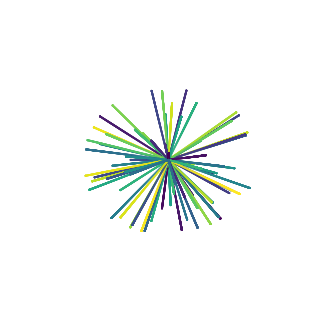

In [6]:
def normalize(img, percentile=90):
    return img / np.percentile(img.ravel(), percentile)

# Plot 3D Coordinates
fig = plt.figure(figsize=(4, 4), dpi=100)
ax = plt.axes(projection='3d')

n_visual = max(1, nviews // 200)
colors = iter(plt.cm.viridis(np.linspace(0, 1, n_visual)))
view_indices = np.linspace(0, nviews - 1, n_visual).astype(int)

for idx in view_indices:
    ax.scatter(
        coord[0, idx, :, 0], 
        coord[0, idx, :, 1], 
        coord[0, idx, :, 2], 
        color=next(colors), s=0.5, marker='.'
    )

ax.set_zlabel('$k_z$')
ax.set_ylabel('$k_y$')
ax.set_xlabel('$k_x$')
plt.axis("off")
plt.show()

## 6 - Estimate k-space preconditioner

Calculating preconditioner...
dens.shape: (6, 1, 14459, 598)


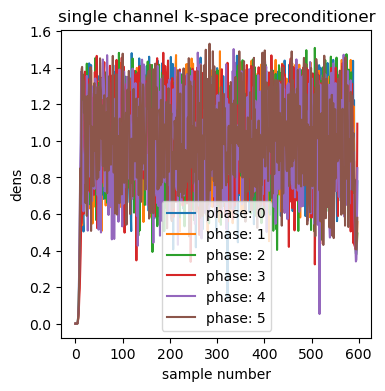

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal.windows import tukey

# -------------------------------------------------------------------------
# 1. CONFIGURATION & FLAGS
# -------------------------------------------------------------------------

use_dcf = False          # Use Pipe-Menon DCF instead of preconditioning
t2star_weighting = False # Additional T2* weighting to the density compensation function

print("Calculating preconditioner...")
dens = np.zeros((nphase, 1, nviews, nread))

# -------------------------------------------------------------------------
# 2. PRE-PROCESSING / VECTORIZED CALCULATIONS
# -------------------------------------------------------------------------

# Pre-calculate T2* relaxation curve if needed (Vectorized)
if t2star_weighting:
    t2_star = 9          # ms (Assumed for 0.55T MRI data, adjust as needed)
    readout = 5          # ms
    dwell_time = readout / nread
    time_axis = np.arange(nread) * dwell_time
    relaxation = np.exp(-time_axis / t2_star) ** 0.5
    
# Pre-calculate Tukey window if needed
if use_dcf:
    tukey_window = tukey(2 * nread, alpha=0.1)
    dens_weighting = tukey_window[nread:]

# -------------------------------------------------------------------------
# 3. MAIN PROCESSING LOOP (PER PHASE)
# -------------------------------------------------------------------------

for resp in range(nphase):
    current_coord = coord[resp, ...]
    
    if use_dcf:
        dcf_result = mr.pipe_menon_dcf(current_coord, matrix_a, device=device, max_iter=30)
        dens[resp, 0, ...] = mvc(dcf_result) * dens_weighting
        
    else:
        # Precondition using Frank Ong's convex optimization problem 
        # TODO: decide on the correct matrix size to use here
        mps_precond = np.ones((1,) + matrix_a) 
        mps_precond /= len(mps_precond) ** 0.5
        
        precond_result = mr.kspace_precond(
            mps_precond,
            coord=sp.to_device(current_coord, device),
            device=sp.Device(device), 
            lamda=1e-2, 
            oversamp=1.5
        )
        dens[resp, 0, ...] = mvc(precond_result)
        
    if t2star_weighting:
        dens[resp, 0, ...] *= relaxation

# -------------------------------------------------------------------------
# 4. NORMALIZATION
# -------------------------------------------------------------------------

print(f"dens.shape: {dens.shape}")

# Normalize all to the same relative intensity
dens /= np.median(dens) 

# -------------------------------------------------------------------------
# 5. PLOTTING & VISUALIZATION
# -------------------------------------------------------------------------

fig, ax1 = plt.subplots(1, figsize=(4, 4), dpi=100)

for resp in range(nphase):
    ax1.plot(np.arange(nread), dens[resp, 0, 0, :], label=f'phase: {resp}') 

ax1.set_ylabel('dens')
ax1.set_xlabel("sample number")
ax1.set_title("Pipe-Menon density compensation" if use_dcf else "single channel k-space preconditioner")
ax1.legend()
plt.show()

## 7 - Coil Compression 

Running coil compression on all data combined into one array...
ksp.shape before coil compression: (6, 32, 14459, 598)


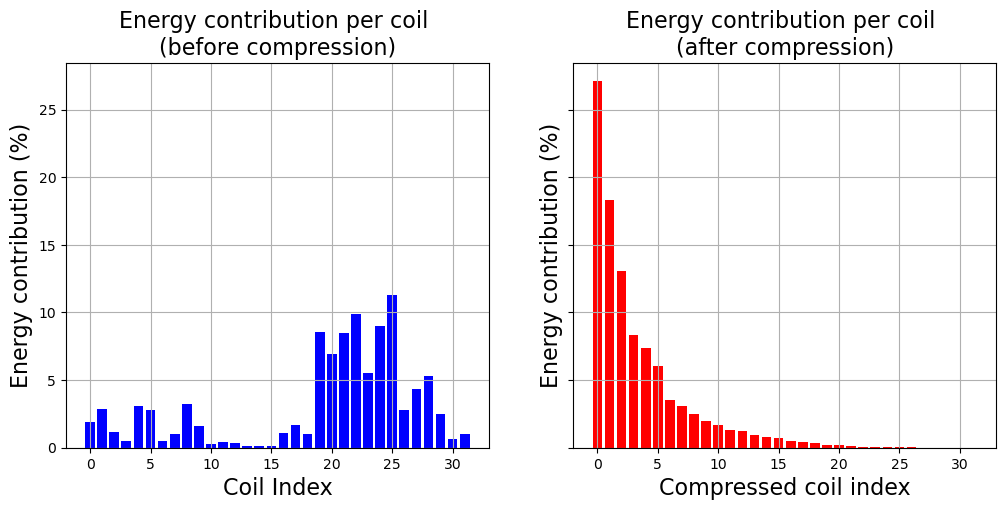

Percent energy per coil: [2.710e+01 1.835e+01 1.305e+01 8.360e+00 7.360e+00 6.010e+00 3.520e+00
 3.100e+00 2.480e+00 1.970e+00 1.670e+00 1.330e+00 1.210e+00 9.300e-01
 8.100e-01 6.900e-01 5.300e-01 4.200e-01 3.200e-01 2.400e-01 1.900e-01
 1.300e-01 8.000e-02 6.000e-02 4.000e-02 3.000e-02 2.000e-02 1.000e-02
 1.000e-02 0.000e+00 0.000e+00 0.000e+00]
10 coils contain 90% of the total energy (for reference only).
eigenvalues[...,-4:] following coil-compression: ...[33.59032  15.780749 10.072476  5.124677]
DYNAMIC COMPRESSION: Retaining top 90% of energy. Reduced from 32 to 10 coils.


In [8]:
# ==============================================================================
# COIL COMPRESSION PROCESSING
# ==============================================================================
if cfg.compress:
    nc0 = ksp.shape[1]
    
    # --------------------------------------------------------------------------
    # Case 1: Combine all data into a single array for compression
    # --------------------------------------------------------------------------
    if cfg.combine_csm: 
        print("Running coil compression on all data combined into one array...")
        print(f"ksp.shape before coil compression: {ksp.shape}")
        
        # Vectorized reshape: Move coil axis to front, merge phase & views
        ksp_full = ksp.transpose(1, 0, 2, 3).reshape(nc0, nphase * nviews, nread)
        ksp_full = mvd(ksp_full)
        
        # Apply compression (returns the dynamically calculated 'nc')
        ksp_full, eigenvalues, nc = coil_compression(ksp_full, percentile=cfg.coil_percentile, chnk=True)
        ksp_full = mvc(ksp_full)
        
        # Vectorized restore: Reshape and transpose back to original dimensions
        ksp = ksp_full.reshape(nc0, nphase, nviews, nread).transpose(1, 0, 2, 3)
        ksp = mvc(ksp)
        
        print(f"eigenvalues[...,-4:] following coil-compression: ...{eigenvalues[-4:]}")
        del ksp_full

    # --------------------------------------------------------------------------
    # Case 2: Compress each respiratory frame individually
    # --------------------------------------------------------------------------
    else:      
        print("Running coil compression on each respiratory frame...")
        ksp = mvd(ksp[:, :, :nviews, ...])
        print(f"ksp.shape before coil compression: {ksp.shape}")
        
        for resp in range(nphase):
            ksp[resp, ...], eigenvalues, nc = coil_compression(ksp[resp, ...], percentile=cfg.coil_percentile)
            print(f"phase {resp}: eigenvalues[...,-4:] following coil-compression: ...{eigenvalues[-4:]}")
            
        ksp = mvc(ksp)
        
    # --------------------------------------------------------------------------
    # Channel Reduction Rules & Overrides
    # --------------------------------------------------------------------------
    print(f"DYNAMIC COMPRESSION: Retaining top {cfg.coil_percentile}% of energy. Reduced from {nc0} to {nc} coils.")

    # Override: Maximize signal (Replaces the hardcoded 'pdw' check)
    if hasattr(cfg, 'keep_all_coils') and cfg.keep_all_coils:
        nc = nc0
        print("CONFIG OVERRIDE: Not truncating coils (aiming to maximize signal).")

# ==============================================================================
# SUBSAMPLE COIL CHANNELS & VARIABLE DECLARATION
# ==============================================================================
# Slices the array down to the dynamically calculated 'nc'
ksp_us = ksp[:, :nc, :nviews, ...] 
coord_us = coord[:, :nviews, ...] 
dens_us = dens[:, :, :nviews, ...]

del ksp

## 8 - Coil Sensitivty Maps

Starting CSM calculation with 10 coils...
Calculating CSM for all phases combined together (with dcf)...


PipeMenonDCF:   0%|          | 0/30 [00:00<?, ?it/s]

The total number of elements in the kspace data is too large, so we will downsample the kspace data and reconstruct a smaller ESPIRIT map, then resize at the end.


EspiritCalib:   0%|          | 0/100 [00:00<?, ?it/s]

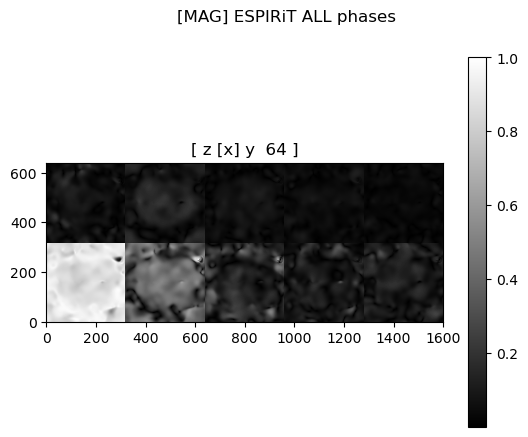

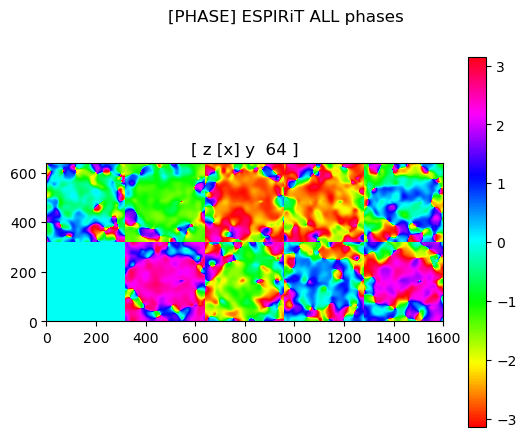

Overwriting individual sensitivity maps with the combined map.
CSM calculation complete. GPU memory freed.


In [9]:
# Define dimensions based on config and data
nc = 10  # Reduced to 10 coils as requested
nphase = ksp_us.shape[0]
nviews = ksp_us.shape[2] 
nread = ksp_us.shape[3]
folder = output_dir
print(f"Starting CSM calculation with {nc} coils...")

# Initialize sensitivity maps array
mps = np.zeros([nphase, nc] + list(matrix_r), dtype=complex)


# ---- Individual Phase CSM Estimation ----
if not cfg.combine_csm:
    print("Calculating CSM for each phase individually...")
    
    for resp in range(nphase):
        # Extract slices for readability
        ksp_resp = ksp_us[resp, :nc, ...]
        coord_resp = coord_us[resp, ...]
        dens_resp = dens_us[resp, 0, ...]
        
        if cfg.espirit_csm:
            mps[resp, ...] = csm.espirit_csm(
                ksp_resp, coord_resp, dens_resp, matrix_r, device, 
                crop=0, thresh=0.02, kernel_width=6, calib_width=24, max_iter=100
            ).get()
            method = "ESPIRiT"
        else:
            mps[resp, ...] = csm.jsense_csm(
                ksp_resp, coord_resp, dens_resp, matrix_r, device,
                mps_ker_width=5, ksp_calib_width=24, lamda=1e-4
            )
            method = "J-SENSE"

        # Plotting
        sp.plot.ImagePlot(mps[resp], x=1, y=2, z=0, colormap='gray', mode='m',
                          title=f"[MAG] {method} respiratory phase {resp}")
        sp.plot.ImagePlot(mps[resp], x=1, y=2, z=0, colormap='hsv', mode='p',
                          title=f"[PHASE] {method} respiratory phase {resp}")

    # Save NIfTI for phase 0
    ni_img = nib.Nifti1Image(crop_center(abs(np.moveaxis(mps[0, ...], 0, -1)), matrix_c), affine=affine_matrix)
    nib.save(ni_img, f"{folder}/sketching/csm_phase_0")


# ---- Combined Phase CSM Estimation ----
if cfg.combine_csm:
    print("Calculating CSM for all phases combined together (with dcf)...")
    
    # Reshape k-space and coordinates across all phases
    ksp_full = np.zeros((nc, nphase * nviews, nread), dtype=complex)
    for coil in range(nc):
        ksp_full[coil, ...] = ksp_us[:, coil, ...].reshape((nphase * nviews, nread))
        
    coord_full = coord_us.reshape((nphase * nviews, nread, 3))
    
    if cfg.espirit_csm:
        dens_full = mvc(mr.pipe_menon_dcf(coord_full, matrix_a, device=device, max_iter=30, width=3.5, beta=8))
        tukey_window = tukey(2 * nread, alpha=0.1)
        dens_full *= tukey_window[nread:]
        
        mps_full = csm.espirit_csm(
            ksp_full, coord_full, dens_full, matrix_r, device, 
            crop=0, thresh=0.02, kernel_width=6, calib_width=20, max_iter=100, downscale_factor=2
        ).get()
        method = "ESPIRiT"
        
    else:
        mps_precond = np.ones((1,) + tuple(matrix_a))
        mps_precond /= len(mps_precond)**0.5
        dens_full = mvc(mr.kspace_precond(
            mps_precond, coord=sp.to_device(coord_full, device), device=sp.Device(device), lamda=1e-2, oversamp=1.5
        ))[0, ...]
        
        mps_full = mvc(sp.mri.app.JsenseRecon(
            ksp_full, coord=coord_full, weights=dens_full, mps_ker_width=5, ksp_calib_width=20, 
            lamda=1e-2, img_shape=matrix_r, device=device, max_iter=30, max_inner_iter=20, show_pbar=True
        ).run())
        method = "J-SENSE NLINV"

    # Plotting Combined Maps
    sp.plot.ImagePlot(mps_full, x=1, y=2, z=0, colormap='gray', mode='m', vmax=1,
                      title=f"[MAG] {method} ALL phases")
    sp.plot.ImagePlot(mps_full, x=1, y=2, z=0, colormap='hsv', mode='p',
                      title=f"[PHASE] {method} ALL phases")
    
    # Broadcast full maps to all respiratory phases
    print("Overwriting individual sensitivity maps with the combined map.")
    for resp in range(nphase):
        mps[resp, ...] = mps_full
        
    # Save Combined NIfTI
    ni_img = nib.Nifti1Image(crop_center(abs(np.moveaxis(mps[0, ...], 0, -1)), matrix_c), affine=affine_matrix)
    nib.save(ni_img, f"{folder}/sketching/csm_phase_combined")

    del ksp_full, coord_full, dens_full


# ---- GPU Memory Cleanup ----
cp._default_memory_pool.free_all_blocks()
print("CSM calculation complete. GPU memory freed.")

## 9 - Recon (simple)

### 9a - Get Max Eigen Value safely

In [11]:
import numpy as np
import cupy as cp
import sigpy as sp
import custom_linop

if cfg.combine_csm and len(mps.shape) == 5:
    print("combine_csm is True: Slicing 5D mps to 4D to save memory.")
    mps_recon = mvc(mps)[0, ...]  
else:
    print("Using full phase-resolved 5D CSMs.")
    mps_recon = mvc(mps)
    
# 1. Clear memory just in case
cp.get_default_memory_pool().free_all_blocks()
cp._default_memory_pool.free_all_blocks()

print("Calculating Maximum Eigenvalue (Bypassing CURAND)...")

# 2. Setup the subset operator
subset_phase = 0 
A_subset = custom_linop.Sense4D(
    mps_recon, 
    coord=coord_us[subset_phase:subset_phase+1, ...], 
    weights=dens_us[subset_phase:subset_phase+1, ...], 
    device=sp.Device(cfg.devnum), 
    coil_batch_size=cfg.nch
)

# 3. Manual Power Iteration
# Force the context specifically to your target device to avoid multi-GPU cross-talk
with sp.Device(cfg.devnum):
    # Generate random array on CPU (NumPy) to dodge the CURAND_STATUS_LAUNCH_FAILURE
    print(f"Generating random {A_subset.N.ishape} array on CPU...")
    x_cpu = np.random.randn(*A_subset.N.ishape) + 1j * np.random.randn(*A_subset.N.ishape)
    
    # Push to GPU
    x_gpu = cp.array(x_cpu, dtype=ksp_us.dtype)
    
    print("Running 30 power iterations...")
    for i in range(30):
        y_gpu = A_subset.N(x_gpu)
        calculated_max_eig = cp.linalg.norm(y_gpu).item()
        x_gpu = y_gpu / calculated_max_eig  # Normalize for next iteration
        
    # Add the 10% safety margin standard to the sketching app
    safe_max_eig = calculated_max_eig * 1.1 
    print(f"**** MAX EIGENVALUE CALCULATED AS {safe_max_eig} ****")

# 4. Burn the evidence to free VRAM
del A_subset, x_gpu, y_gpu, x_cpu
cp._default_memory_pool.free_all_blocks()

combine_csm is True: Slicing 5D mps to 4D to save memory.
Calculating Maximum Eigenvalue (Bypassing CURAND)...
Using the same CSM for all respiratory phases.
Coil batch size of 3 coils supplied to Sense4D().
Coil batching with 3 coils out of 10 total coils.
Using the same CSM for all respiratory phases.
Automated coil batch size = 3 set to nc = 3 inside Sense4D().
Using the same CSM for all respiratory phases.
Automated coil batch size = 3 set to nc = 3 inside Sense4D().
Using the same CSM for all respiratory phases.
Automated coil batch size = 3 set to nc = 3 inside Sense4D().
Using the same CSM for all respiratory phases.
Automated coil batch size = 1 set to nc = 1 inside Sense4D().
Generating random [1, 320, 320, 128] array on CPU...
Running 30 power iterations...
**** MAX EIGENVALUE CALCULATED AS 6.512816762924195 ****


In [12]:
# =============================================================================
# 4D Reconstruction (Low Rank, No Motion Compensation)
# =============================================================================
import sketching_4d_app as sk4d
# 1. Clear GPU Memory
cp.get_default_memory_pool().free_all_blocks()
cp.get_default_pinned_memory_pool().free_all_blocks()
cp._default_memory_pool.free_all_blocks()

# 2. Set Random Seed 
np.random.seed(1)

print(f"Starting 4D Low Rank Recon (No MoCo) using {cfg.nch} coils on Device {cfg.devnum}...")

# 3. Initialize and Run the Reconstruction App
app_no_moco = sk4d.SketchedLowRankRecon4D(
    y=ksp_us / cfg.scale,                  
    mps=mps_recon, 
    lamda=cfg.lamda,                       
    reduced_ncoils=cfg.nch,                
    weights=dens_us, 
    coord=coord_us,
    moco=False,                            
    solver='PrimalDualHybridGradient', 
    max_eig=safe_max_eig,                  # <--- VITAL: Bypasses the CURAND memory crash
    toeplitz=cfg.toeplitz,                 
    show_pbar=True, 
    device=sp.Device(cfg.devnum),          
    number_non_sketched_coils=cfg.num_non_sketched_coils, 
    max_init_iter=cfg.max_init_iter,           
    max_outer_iter=cfg.max_outer_iter,         
    max_inner_iter=cfg.max_inner_iter,         
    max_power_iter=cfg.max_power_iter,     # (Ignored now because max_eig is provided, but safe to leave)
    save_objective_values=False, 
    coil_batch_size=cfg.nch                
)

# Run app and scale back
img_sk_lr_no_moco = app_no_moco.run()
img_sk_lr_no_moco = mvc(cfg.scale * img_sk_lr_no_moco)

# 4. Save NIfTI
img_cropped = crop_center(abs(np.moveaxis(img_sk_lr_no_moco, 0, -1)), matrix_c)
ni_img = nib.Nifti1Image(img_cropped, affine=affine_matrix) 
nib.save(ni_img, f"{output_dir}/sketching/img_sk_lr_no_moco") 
print("Reconstruction saved successfully.")

# 5. Clear GPU Memory 
cp._default_memory_pool.free_all_blocks()

# =============================================================================
# Visualization
# =============================================================================
print(f"Generating Sagittal comparison...")
fig, ax = plt.subplots(1, 1, figsize=(6, 4))  

sag_slice = 6 * matrix_c[0] // 10
img_tmp = crop_center(np.moveaxis(img_sk_lr_no_moco, 0, -1), (matrix_c[0], matrix_c[1], int(cfg.res_scale * matrix_e[2])))

img_insp = np.rot90(normalize(abs(img_tmp[..., nphase // 2])), k=1)  
img_exp = np.rot90(normalize(abs(img_tmp[..., 0])), k=1)

sag_exp = np.rot90(img_exp[sag_slice, :, :], k=2)
sag_insp = np.rot90(img_insp[sag_slice, :, :], k=2)

concat_img = np.concatenate((sag_exp, sag_insp), axis=1)
im = ax.imshow(concat_img, cmap='gray', vmax=1)
ax.set_title("Expiration (Left) vs Inspiration (Right) - No MoCo")
ax.axis('off')

fig.savefig(f"{output_dir}/sketching/png/sketched_img_{cfg.nch}_coils_lr_no_moco.png", bbox_inches='tight', pad_inches=0)
plt.show()

Starting 4D Low Rank Recon (No MoCo) using 3 coils on Device 0...
Not regularizing the motion compensated images.
Using PDHG to solve the reconstruction problem.
Double checking... self.solver = None
self.device = <CUDA Device 0>
Using a coil batch size of 3 in this reconstruction.
Using the same CSM for all respiratory phases.
Coil batch size of 3 coils supplied to Sense4D().
Coil batching with 3 coils out of 10 total coils.
Using the same CSM for all respiratory phases.
Automated coil batch size = 3 set to nc = 3 inside Sense4D().
Using the same CSM for all respiratory phases.
Automated coil batch size = 3 set to nc = 3 inside Sense4D().
Using the same CSM for all respiratory phases.
Automated coil batch size = 3 set to nc = 3 inside Sense4D().
Using the same CSM for all respiratory phases.
Automated coil batch size = 1 set to nc = 1 inside Sense4D().
Not using Toeplitz PSF, moving coord and weights to device <CUDA Device 0> for faster NUFFT calculations.
self.coord device = <CUDA De

CURANDError: CURAND_STATUS_LAUNCH_FAILURE